In [4]:
# Imports base
import os
import copy
import json
import random
import itertools
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

import mlflow


/home/rami/miniconda3/envs/skin-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/rami/miniconda3/envs/skin-env/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [5]:
# Reproducibilidad global
GLOBAL_SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(GLOBAL_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [6]:
# Paths y experimento
train_dir = "data/Split_smol/train"
val_dir = "data/Split_smol/val"

EXPERIMENT_NAME = "Clasificador_Imagenes_MLP_Optimizado_vv3"
mlflow.set_experiment(EXPERIMENT_NAME)

base_log_dir = "runs/mlp_optimizado_vv3"
artifact_dir = "artifacts_vv3"
os.makedirs(base_log_dir, exist_ok=True)
os.makedirs(artifact_dir, exist_ok=True)


In [7]:
# Dataset con encoder compartido train/val
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None, classes=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

        if classes is None:
            self.classes = sorted([p.name for p in self.root_dir.iterdir() if p.is_dir()])
        else:
            self.classes = list(classes)

        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        self.samples = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = self.root_dir / cls_name
            if not cls_dir.exists():
                continue
            for path in cls_dir.rglob("*"):
                if path.suffix.lower() in self.extensions:
                    label = self.class_to_idx[cls_name]
                    self.samples.append((str(path), label))
                    self.labels.append(label)

        if len(self.samples) == 0:
            raise ValueError(f"No se encontraron imágenes en: {self.root_dir}")

        # Compatibilidad con código previo.
        self.label_encoder = SimpleNamespace(classes_=np.array(self.classes))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        if self.transform is not None:
            image = self.transform(image=image)["image"]

        return image, label


In [8]:
# MLP puro: Linear + LayerNorm + GELU + Dropout
class MLPClassifier(nn.Module):
    def __init__(self, num_classes, input_size, hidden_sizes=(1024, 512), dropout=0.35):
        super().__init__()

        layers = []
        in_features = input_size

        for hidden in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden))
            layers.append(nn.LayerNorm(hidden))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            in_features = hidden

        layers.append(nn.Linear(in_features, num_classes))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.net(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [9]:
# Transforms: train con augmentation, train_eval/val sin augmentation
def build_transforms(input_size, hflip, vflip, rb_contrast):
    train_transform = A.Compose([
        A.Resize(input_size, input_size),
        A.HorizontalFlip(p=hflip),
        A.VerticalFlip(p=vflip),
        A.RandomBrightnessContrast(p=rb_contrast),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    eval_transform = A.Compose([
        A.Resize(input_size, input_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    return train_transform, eval_transform


def build_loaders(hparams):
    train_transform, eval_transform = build_transforms(
        input_size=hparams["input_size"],
        hflip=hparams["HFlip"],
        vflip=hparams["VFlip"],
        rb_contrast=hparams["RBContrast"],
    )

    # Train real: con augmentation.
    train_dataset = CustomImageDataset(hparams["train_dir"], transform=train_transform)

    # Train eval: mismo train, pero sin augmentation.
    train_eval_dataset = CustomImageDataset(
        hparams["train_dir"],
        transform=eval_transform,
        classes=train_dataset.classes,
    )

    # Validation: sin augmentation y con mismo encoder.
    val_dataset = CustomImageDataset(
        hparams["val_dir"],
        transform=eval_transform,
        classes=train_dataset.classes,
    )

    assert np.array_equal(train_dataset.label_encoder.classes_, val_dataset.label_encoder.classes_),         "Train y val tienen clases codificadas distinto"

    num_workers = hparams.get("num_workers", 0)
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=hparams["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    train_eval_loader = DataLoader(
        train_eval_dataset,
        batch_size=hparams["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=hparams["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_dataset, train_eval_dataset, val_dataset, train_loader, train_eval_loader, val_loader


In [10]:
# Evaluación: devuelve métricas y predicciones
@torch.no_grad()
def evaluate(model, loader, criterion, device, writer=None, epoch=None, prefix="val"):
    model.eval()

    losses = []
    all_preds = []
    all_labels = []

    for i, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(dim=1)

        losses.append(loss.item())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Imagen de muestra mínima para TensorBoard.
        if writer is not None and epoch is not None and i == 0:
            img_grid = vutils.make_grid(images[:8].cpu(), normalize=True)
            writer.add_image(f"{prefix}/images", img_grid, global_step=epoch)

    avg_loss = float(np.mean(losses))
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    if writer is not None and epoch is not None:
        writer.add_scalar(f"{prefix}/loss", avg_loss, epoch)
        writer.add_scalar(f"{prefix}/accuracy", acc, epoch)
        writer.add_scalar(f"{prefix}/macro_f1", macro_f1, epoch)
        writer.add_scalar(f"{prefix}/balanced_accuracy", balanced_acc, epoch)

    return avg_loss, acc, macro_f1, balanced_acc, np.array(all_labels), np.array(all_preds)


In [11]:
# Reportes: confusion matrix + métricas por clase

def save_final_reports(y_true, y_pred, classes, run_label):
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0,
        output_dict=True,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0,
    )

    report_txt_path = f"{artifact_dir}/classification_report_{run_label}.txt"
    with open(report_txt_path, "w") as f:
        f.write(report_text)

    per_class_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class"})
    per_class_csv_path = f"{artifact_dir}/per_class_metrics_{run_label}.csv"
    per_class_df.to_csv(per_class_csv_path, index=False)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    cm_csv_path = f"{artifact_dir}/confusion_matrix_{run_label}.csv"
    cm_df.to_csv(cm_csv_path)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix - {run_label}")
    plt.tight_layout()
    cm_png_path = f"{artifact_dir}/confusion_matrix_{run_label}.png"
    fig.savefig(cm_png_path, dpi=150)
    plt.close(fig)

    # Errores por clase: 1 - recall.
    class_rows = per_class_df[per_class_df["class"].isin(classes)].copy()
    class_rows["error_rate"] = 1.0 - class_rows["recall"]
    error_csv_path = f"{artifact_dir}/per_class_errors_{run_label}.csv"
    class_rows.sort_values("error_rate", ascending=False).to_csv(error_csv_path, index=False)

    for path in [report_txt_path, per_class_csv_path, cm_csv_path, cm_png_path, error_csv_path]:
        mlflow.log_artifact(path)

    return {
        "report_text": report_text,
        "per_class_df": per_class_df,
        "cm_df": cm_df,
        "worst_classes_df": class_rows.sort_values("error_rate", ascending=False),
    }


In [12]:
# Config base: trial 53 de la búsqueda previa
TRIAL53_HPARAMS = {
    "model": "MLPClassifier",
    "loss_fn": "CrossEntropyLoss_weighted_label_smoothing",
    "train_dir": train_dir,
    "val_dir": val_dir,
    "epochs": 200,
    "es_patience": 12,
    "label_smoothing": 0.05,
    "grad_clip_norm": 1.0,
    "scheduler_factor": 0.5,
    "scheduler_patience": 4,
    "num_workers": 0,
    "input_size": 64,
    "batch_size": 64,
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "hidden_sizes": (1024, 512),
    "dropout": 0.35,
    "HFlip": 0.5,
    "VFlip": 0.5,
    "RBContrast": 0.3,
}

# La búsqueda anterior usaba set_seed(42 + trial_id), entonces trial 53 equivale a seed 95.
TRIAL53_SEEDS = [95, 1, 7, 21, 42, 123]


In [13]:
# Espacio local alrededor del trial 53
LOCAL_SPACE = {
    "input_size": [64, 80, 96],
    "batch_size": [32, 64],
    "lr": [5e-5, 1e-4, 2e-4],
    "weight_decay": [5e-4, 1e-3, 2e-3],
    "hidden_sizes": [(768, 384), (1024, 512), (1024, 512, 256), (1536, 768)],
    "dropout": [0.25, 0.35, 0.45, 0.55],
    "label_smoothing": [0.0, 0.03, 0.05, 0.1],
    "HFlip": [0.5],
    "VFlip": [0.5],
    "RBContrast": [0.3, 0.5],
}

N_LOCAL_TRIALS = 50  # Subí esto si querés una búsqueda más exhaustiva.
LOCAL_SEARCH_SEED = 2026

def sample_local_configs(space, n_trials=50, seed=2026):
    keys = list(space.keys())
    values = [space[k] for k in keys]

    configs = []
    for combo in itertools.product(*values):
        cfg = copy.deepcopy(TRIAL53_HPARAMS)
        cfg.update(dict(zip(keys, combo)))
        configs.append(cfg)

    rng = random.Random(seed)
    rng.shuffle(configs)

    # Evita duplicados explícitos y limita cantidad.
    selected = []
    seen = set()
    for cfg in configs:
        signature = tuple((k, str(cfg[k])) for k in sorted(cfg.keys()))
        if signature not in seen:
            selected.append(cfg)
            seen.add(signature)
        if len(selected) >= n_trials:
            break
    return selected

local_configs = sample_local_configs(LOCAL_SPACE, n_trials=N_LOCAL_TRIALS, seed=LOCAL_SEARCH_SEED)
print("configs locales:", len(local_configs))


configs locales: 50


In [14]:
# Helpers para MLflow/JSON

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def params_for_log(hparams):
    out = copy.deepcopy(hparams)
    out["hidden_sizes"] = str(out["hidden_sizes"])
    return out


In [15]:
# Entrenamiento de una configuración con una seed

def train_one_config(hparams, run_label, seed):
    set_seed(seed)

    train_dataset, train_eval_dataset, val_dataset, train_loader, train_eval_loader, val_loader = build_loaders(hparams)
    classes = train_dataset.label_encoder.classes_
    num_classes = len(classes)
    input_dim = hparams["input_size"] ** 2 * 3

    model = MLPClassifier(
        num_classes=num_classes,
        input_size=input_dim,
        hidden_sizes=hparams["hidden_sizes"],
        dropout=hparams["dropout"],
    ).to(device)

    # Pesos por clase: reduce colapso a clases frecuentes.
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=np.array(train_dataset.labels),
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=hparams["label_smoothing"],
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=hparams["lr"],
        weight_decay=hparams["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=hparams["scheduler_factor"],
        patience=hparams["scheduler_patience"],
    )

    log_hparams = params_for_log(hparams)
    log_hparams.update({
        "seed": seed,
        "count_params": count_parameters(model),
        "num_classes": num_classes,
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
    })

    writer = SummaryWriter(log_dir=os.path.join(base_log_dir, run_label))

    best_state = None
    best_epoch = -1
    best_val_macro_f1 = -1.0
    best_metrics = {}

    with mlflow.start_run(run_name=run_label):
        mlflow.log_params(log_hparams)

        pbar = tqdm(range(hparams["epochs"]), desc=run_label, leave=True)
        for epoch in pbar:
            model.train()
            train_losses = []
            train_preds = []
            train_labels = []

            for images, labels in train_loader:
                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()

                # Estabiliza updates del MLP grande.
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=hparams["grad_clip_norm"],
                )

                optimizer.step()

                preds = outputs.argmax(dim=1)
                train_losses.append(loss.item())
                train_preds.extend(preds.detach().cpu().numpy())
                train_labels.extend(labels.detach().cpu().numpy())

            train_aug_loss = float(np.mean(train_losses))
            train_aug_acc = accuracy_score(train_labels, train_preds)
            train_aug_macro_f1 = f1_score(train_labels, train_preds, average="macro", zero_division=0)

            val_loss, val_acc, val_macro_f1, val_bal_acc, y_true, y_pred = evaluate(
                model=model,
                loader=val_loader,
                criterion=criterion,
                device=device,
                writer=writer,
                epoch=epoch,
                prefix="val",
            )

            scheduler.step(val_macro_f1)
            current_lr = optimizer.param_groups[0]["lr"]

            writer.add_scalar("train_aug/loss", train_aug_loss, epoch)
            writer.add_scalar("train_aug/accuracy", train_aug_acc, epoch)
            writer.add_scalar("train_aug/macro_f1", train_aug_macro_f1, epoch)
            writer.add_scalar("train/lr", current_lr, epoch)

            mlflow.log_metrics({
                "train_aug_loss": train_aug_loss,
                "train_aug_accuracy": train_aug_acc,
                "train_aug_macro_f1": train_aug_macro_f1,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "val_macro_f1": val_macro_f1,
                "val_balanced_accuracy": val_bal_acc,
                "lr": current_lr,
            }, step=epoch)

            pbar.set_postfix({
                "val_f1": f"{val_macro_f1:.3f}",
                "val_acc": f"{val_acc:.3f}",
                "best_f1": f"{best_val_macro_f1:.3f}",
            })

            # Selección por macro F1.
            if val_macro_f1 > best_val_macro_f1:
                best_val_macro_f1 = val_macro_f1
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                best_metrics = {
                    "best_epoch": best_epoch,
                    "best_train_aug_loss": train_aug_loss,
                    "best_train_aug_accuracy": train_aug_acc,
                    "best_train_aug_macro_f1": train_aug_macro_f1,
                    "best_val_loss": val_loss,
                    "best_val_accuracy": val_acc,
                    "best_val_macro_f1": val_macro_f1,
                    "best_val_balanced_accuracy": val_bal_acc,
                }

            elif epoch > best_epoch + hparams["es_patience"]:
                tqdm.write(
                    f"Early stopping {run_label}: epoch {epoch + 1}/{hparams['epochs']} | "
                    f"best_epoch={best_epoch + 1} | best_val_macro_f1={best_val_macro_f1:.4f}"
                )
                break

        model.load_state_dict(best_state)

        # Eval final del mejor checkpoint: train sin augmentation y val.
        train_eval_loss, train_eval_acc, train_eval_macro_f1, train_eval_bal_acc, _, _ = evaluate(
            model=model,
            loader=train_eval_loader,
            criterion=criterion,
            device=device,
            writer=None,
            epoch=None,
            prefix="train_eval",
        )

        val_loss, val_acc, val_macro_f1, val_bal_acc, y_true, y_pred = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            writer=None,
            epoch=None,
            prefix="val_final",
        )

        final_metrics = {
            **best_metrics,
            "final_train_eval_loss": train_eval_loss,
            "final_train_eval_accuracy": train_eval_acc,
            "final_train_eval_macro_f1": train_eval_macro_f1,
            "final_train_eval_balanced_accuracy": train_eval_bal_acc,
            "final_val_loss": val_loss,
            "final_val_accuracy": val_acc,
            "final_val_macro_f1": val_macro_f1,
            "final_val_balanced_accuracy": val_bal_acc,
            "generalization_gap_macro_f1": train_eval_macro_f1 - val_macro_f1,
            "generalization_gap_accuracy": train_eval_acc - val_acc,
        }

        reports = save_final_reports(y_true, y_pred, classes, run_label)
        print(reports["report_text"])
        print("Peores clases por error_rate:")
        display(reports["worst_classes_df"][["class", "precision", "recall", "f1-score", "support", "error_rate"]].head(5))

        # Checkpoint robusto: evita problema de signature/input_example de MLflow.
        checkpoint_path = f"{artifact_dir}/{run_label}.pth"
        torch.save({
            "model_state_dict": model.state_dict(),
            "classes": list(classes),
            "hparams": to_jsonable(hparams),
            "seed": seed,
            "metrics": to_jsonable(final_metrics),
        }, checkpoint_path)
        mlflow.log_artifact(checkpoint_path)

        hparams_json_path = f"{artifact_dir}/hparams_{run_label}.json"
        with open(hparams_json_path, "w") as f:
            json.dump(to_jsonable({**hparams, "seed": seed}), f, indent=2)
        mlflow.log_artifact(hparams_json_path)

        mlflow.log_metrics(final_metrics)

    writer.close()

    result = params_for_log(hparams)
    result.update(final_metrics)
    result["seed"] = seed
    result["run_label"] = run_label
    return result


## 1. Repetir trial 53 con varias seeds

Esto mide si el mejor trial anterior fue robusto o si dependió de una inicialización afortunada.


In [16]:
# Ejecutar repeticiones del trial 53
RUN_REPEATS = True

repeat_results = []
if RUN_REPEATS:
    for seed in TRIAL53_SEEDS:
        run_label = f"repeat_trial53_seed_{seed}"
        print(f"\nRunning {run_label}")
        repeat_results.append(train_one_config(TRIAL53_HPARAMS, run_label=run_label, seed=seed))

repeat_results_df = pd.DataFrame(repeat_results)
if len(repeat_results_df):
    repeat_results_df = repeat_results_df.sort_values("final_val_macro_f1", ascending=False)
    repeat_results_df.to_csv("mlp_vv3_trial53_repeated_seeds.csv", index=False)

repeat_results_df



Running repeat_trial53_seed_95


repeat_trial53_seed_95:  32%|███▏      | 63/200 [02:45<05:58,  2.62s/it, val_f1=0.598, val_acc=0.588, best_f1=0.625]


Early stopping repeat_trial53_seed_95: epoch 64/200 | best_epoch=51 | best_val_macro_f1=0.6253
                            precision    recall  f1-score   support

         Actinic keratosis       0.35      0.45      0.39        20
         Atopic Dermatitis       0.82      0.82      0.82        11
          Benign keratosis       0.86      0.90      0.88        20
            Dermatofibroma       0.53      0.40      0.46        20
         Melanocytic nevus       0.60      0.75      0.67        20
                  Melanoma       0.53      0.45      0.49        20
   Squamous cell carcinoma       0.39      0.35      0.37        20
Tinea Ringworm Candidiasis       0.77      0.71      0.74        14
           Vascular lesion       0.84      0.80      0.82        20

                  accuracy                           0.61       165
                 macro avg       0.63      0.63      0.63       165
              weighted avg       0.62      0.61      0.61       165

Peores clases por 

,class,precision,recall,f1-score,support,error_rate
6,Squamous cell carcinoma,0.388889,0.350000,0.368421,20.0,0.650000
3,Dermatofibroma,0.533333,0.400000,0.457143,20.0,0.600000
0,Actinic keratosis,0.346154,0.450000,0.391304,20.0,0.550000
5,Melanoma,0.529412,0.450000,0.486486,20.0,0.550000
7,Tinea Ringworm Candidiasis,0.769231,0.714286,0.740741,14.0,0.285714



Running repeat_trial53_seed_1


...


Running repeat_trial53_seed_123


repeat_trial53_seed_123:  22%|██▎       | 45/200 [01:57<06:46,  2.62s/it, val_f1=0.570, val_acc=0.558, best_f1=0.602]


Early stopping repeat_trial53_seed_123: epoch 46/200 | best_epoch=33 | best_val_macro_f1=0.6016
                            precision    recall  f1-score   support

         Actinic keratosis       0.38      0.50      0.43        20
         Atopic Dermatitis       0.75      0.82      0.78        11
          Benign keratosis       0.86      0.90      0.88        20
            Dermatofibroma       0.44      0.40      0.42        20
         Melanocytic nevus       0.64      0.80      0.71        20
                  Melanoma       0.44      0.35      0.39        20
   Squamous cell carcinoma       0.31      0.25      0.28        20
Tinea Ringworm Candidiasis       0.82      0.64      0.72        14
           Vascular lesion       0.80      0.80      0.80        20

                  accuracy                           0.59       165
                 macro avg       0.60      0.61      0.60       165
              weighted avg       0.59      0.59      0.59       165

Peores clases por

,class,precision,recall,f1-score,support,error_rate
6,Squamous cell carcinoma,0.312500,0.250000,0.277778,20.0,0.750000
5,Melanoma,0.437500,0.350000,0.388889,20.0,0.650000
3,Dermatofibroma,0.444444,0.400000,0.421053,20.0,0.600000
0,Actinic keratosis,0.384615,0.500000,0.434783,20.0,0.500000
7,Tinea Ringworm Candidiasis,0.818182,0.642857,0.720000,14.0,0.357143


,model,loss_fn,train_dir,val_dir,epochs,es_patience,label_smoothing,grad_clip_norm,scheduler_factor,scheduler_patience,...,final_train_eval_macro_f1,final_train_eval_balanced_accuracy,final_val_loss,final_val_accuracy,final_val_macro_f1,final_val_balanced_accuracy,generalization_gap_macro_f1,generalization_gap_accuracy,seed,run_label
0,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.799098,0.803619,1.323133,0.612121,0.625278,0.625830,0.173820,0.184639,95,repeat_trial53_seed_95
3,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.793001,0.796506,1.326413,0.606061,0.607932,0.613348,0.185069,0.183336,21,repeat_trial53_seed_21
4,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.774979,0.777673,1.344588,0.593939,0.603448,0.602237,0.171530,0.179256,42,repeat_trial53_seed_42
5,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.740415,0.742118,1.341722,0.593939,0.601586,0.606782,0.138830,0.142438,123,repeat_trial53_seed_123
1,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.795564,0.798949,1.318075,0.587879,0.599144,0.596681,0.196420,0.202990,1,repeat_trial53_seed_1
2,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.735381,0.735229,1.363753,0.569697,0.584383,0.582395,0.150998,0.162262,7,repeat_trial53_seed_7


In [17]:
# Resumen estadístico del trial 53 repetido
if len(repeat_results_df):
    repeat_summary = repeat_results_df[[
        "final_val_macro_f1",
        "final_val_accuracy",
        "final_train_eval_macro_f1",
        "generalization_gap_macro_f1",
    ]].agg(["mean", "std", "min", "max"])
    display(repeat_summary)


,final_val_macro_f1,final_val_accuracy,final_train_eval_macro_f1,generalization_gap_macro_f1
mean,0.603628,0.593939,0.773073,0.169444
std,0.013281,0.014845,0.028535,0.021321
min,0.584383,0.569697,0.735381,0.138830
max,0.625278,0.612121,0.799098,0.196420


## 2. Búsqueda local alrededor del trial 53

Busca configs cercanas al mejor trial, en lugar de repetir una búsqueda amplia poco eficiente.


In [18]:
# Ejecutar búsqueda local
RUN_LOCAL_SEARCH = True

local_results = []
if RUN_LOCAL_SEARCH:
    for local_id, cfg in enumerate(local_configs):
        seed = LOCAL_SEARCH_SEED + local_id
        run_label = f"local_{local_id:03d}_seed_{seed}"
        print(f"\nRunning {run_label}: {cfg}")
        local_results.append(train_one_config(cfg, run_label=run_label, seed=seed))

local_results_df = pd.DataFrame(local_results)
if len(local_results_df):
    local_results_df = local_results_df.sort_values("final_val_macro_f1", ascending=False)
    local_results_df.to_csv("mlp_vv3_local_search_results.csv", index=False)

local_results_df.head(10) if len(local_results_df) else local_results_df



Running local_000_seed_2026: {'model': 'MLPClassifier', 'loss_fn': 'CrossEntropyLoss_weighted_label_smoothing', 'train_dir': 'data/Split_smol/train', 'val_dir': 'data/Split_smol/val', 'epochs': 200, 'es_patience': 12, 'label_smoothing': 0.0, 'grad_clip_norm': 1.0, 'scheduler_factor': 0.5, 'scheduler_patience': 4, 'num_workers': 0, 'input_size': 96, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.002, 'hidden_sizes': (1024, 512), 'dropout': 0.45, 'HFlip': 0.5, 'VFlip': 0.5, 'RBContrast': 0.5}


local_000_seed_2026:  40%|████      | 81/200 [03:50<05:38,  2.85s/it, val_f1=0.584, val_acc=0.576, best_f1=0.592]


Early stopping local_000_seed_2026: epoch 82/200 | best_epoch=69 | best_val_macro_f1=0.5919
                            precision    recall  f1-score   support

         Actinic keratosis       0.35      0.40      0.37        20
         Atopic Dermatitis       0.73      0.73      0.73        11
          Benign keratosis       0.90      0.90      0.90        20
            Dermatofibroma       0.50      0.45      0.47        20
         Melanocytic nevus       0.60      0.75      0.67        20
                  Melanoma       0.37      0.35      0.36        20
   Squamous cell carcinoma       0.33      0.30      0.32        20
Tinea Ringworm Candidiasis       0.75      0.64      0.69        14
           Vascular lesion       0.84      0.80      0.82        20

                  accuracy                           0.58       165
                 macro avg       0.60      0.59      0.59       165
              weighted avg       0.58      0.58      0.58       165

Peores clases por err

,class,precision,recall,f1-score,support,error_rate
6,Squamous cell carcinoma,0.333333,0.300000,0.315789,20.0,0.700000
5,Melanoma,0.368421,0.350000,0.358974,20.0,0.650000
0,Actinic keratosis,0.347826,0.400000,0.372093,20.0,0.600000
3,Dermatofibroma,0.500000,0.450000,0.473684,20.0,0.550000
7,Tinea Ringworm Candidiasis,0.750000,0.642857,0.692308,14.0,0.357143



Running local_001_seed_2027: {'model': 'MLPClassifier', 'loss_fn': 'CrossEntropyLoss_weighted_label_smoothing', 'train_dir': 'data/Split_smol/train', 'val_dir': 'data/Split_smol/val', 'epochs': 200, 'es_patience': 12, 'label_smoothing': 0.0, 'grad_clip_norm': 1.0, 'scheduler_factor': 0.5, 'scheduler_patience': 4, 'num_workers': 0, 'input_size': 80, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.001, 'hidden_sizes': (1536, 768), 'dropout': 0.35, 'HFlip': 0.5, 'VFlip': 0.5, 'RBContrast': 0.3}


...


Running local_049_seed_2075: {'model': 'MLPClassifier', 'loss_fn': 'CrossEntropyLoss_weighted_label_smoothing', 'train_dir': 'data/Split_smol/train', 'val_dir': 'data/Split_smol/val', 'epochs': 200, 'es_patience': 12, 'label_smoothing': 0.05, 'grad_clip_norm': 1.0, 'scheduler_factor': 0.5, 'scheduler_patience': 4, 'num_workers': 0, 'input_size': 96, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.001, 'hidden_sizes': (1536, 768), 'dropout': 0.55, 'HFlip': 0.5, 'VFlip': 0.5, 'RBContrast': 0.3}


local_049_seed_2075:  18%|█▊        | 36/200 [01:45<08:00,  2.93s/it, val_f1=0.563, val_acc=0.558, best_f1=0.564]


Early stopping local_049_seed_2075: epoch 37/200 | best_epoch=24 | best_val_macro_f1=0.5637
                            precision    recall  f1-score   support

         Actinic keratosis       0.32      0.40      0.36        20
         Atopic Dermatitis       0.86      0.55      0.67        11
          Benign keratosis       0.90      0.90      0.90        20
            Dermatofibroma       0.35      0.40      0.37        20
         Melanocytic nevus       0.65      0.75      0.70        20
                  Melanoma       0.42      0.40      0.41        20
   Squamous cell carcinoma       0.25      0.15      0.19        20
Tinea Ringworm Candidiasis       0.69      0.79      0.73        14
           Vascular lesion       0.75      0.75      0.75        20

                  accuracy                           0.56       165
                 macro avg       0.58      0.56      0.56       165
              weighted avg       0.56      0.56      0.55       165

Peores clases por err

,class,precision,recall,f1-score,support,error_rate
6,Squamous cell carcinoma,0.250000,0.150000,0.187500,20.0,0.850000
0,Actinic keratosis,0.320000,0.400000,0.355556,20.0,0.600000
3,Dermatofibroma,0.347826,0.400000,0.372093,20.0,0.600000
5,Melanoma,0.421053,0.400000,0.410256,20.0,0.600000
1,Atopic Dermatitis,0.857143,0.545455,0.666667,11.0,0.454545


,model,loss_fn,train_dir,val_dir,epochs,es_patience,label_smoothing,grad_clip_norm,scheduler_factor,scheduler_patience,...,final_train_eval_macro_f1,final_train_eval_balanced_accuracy,final_val_loss,final_val_accuracy,final_val_macro_f1,final_val_balanced_accuracy,generalization_gap_macro_f1,generalization_gap_accuracy,seed,run_label
37,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.794988,0.800616,1.368574,0.624242,0.636158,0.636941,0.158830,0.166627,2063,local_037_seed_2063
1,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.00,1.0,0.5,4,...,0.735066,0.740121,1.094899,0.624242,0.626390,0.636941,0.108677,0.109189,2027,local_001_seed_2027
4,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.00,1.0,0.5,4,...,0.802245,0.803394,1.179035,0.618182,0.626128,0.629004,0.176117,0.180051,2030,local_004_seed_2030
25,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.00,1.0,0.5,4,...,0.763465,0.766840,1.176017,0.612121,0.626054,0.623665,0.137411,0.147820,2051,local_025_seed_2051
44,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.03,1.0,0.5,4,...,0.778056,0.782452,1.303426,0.612121,0.619739,0.621284,0.158317,0.161075,2070,local_044_seed_2070
9,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.03,1.0,0.5,4,...,0.735074,0.739179,1.297709,0.600000,0.616869,0.612554,0.118205,0.130486,2035,local_009_seed_2035
48,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.776997,0.781397,1.267351,0.600000,0.612638,0.610173,0.164359,0.173196,2074,local_048_seed_2074
33,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.03,1.0,0.5,4,...,0.767633,0.768788,1.191463,0.600000,0.610957,0.608009,0.156676,0.161414,2059,local_033_seed_2059
34,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.03,1.0,0.5,4,...,0.691914,0.691176,1.296573,0.600000,0.608993,0.612338,0.082921,0.089249,2060,local_034_seed_2060
36,MLPClassifier,CrossEntropyLoss_weighted_label_smoothing,data/Split_smol/train,data/Split_smol/val,200,12,0.05,1.0,0.5,4,...,0.745784,0.750898,1.216090,0.600000,0.607873,0.610173,0.137911,0.143741,2062,local_036_seed_2062


## 3. Ranking combinado

Compara repeticiones del trial 53 contra la búsqueda local.


In [19]:
# Ranking final combinado
frames = []
if len(repeat_results_df):
    tmp = repeat_results_df.copy()
    tmp["stage"] = "repeat_trial53"
    frames.append(tmp)
if len(local_results_df):
    tmp = local_results_df.copy()
    tmp["stage"] = "local_search"
    frames.append(tmp)

combined_results_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
if len(combined_results_df):
    combined_results_df = combined_results_df.sort_values("final_val_macro_f1", ascending=False)
    combined_results_df.to_csv("mlp_vv3_combined_results.csv", index=False)

cols = [
    "stage", "run_label", "seed",
    "input_size", "batch_size", "lr", "weight_decay", "hidden_sizes", "dropout",
    "label_smoothing", "VFlip", "RBContrast",
    "best_epoch", "final_train_eval_macro_f1", "final_val_macro_f1",
    "final_val_accuracy", "final_val_balanced_accuracy", "generalization_gap_macro_f1",
]
combined_results_df[cols].head(15) if len(combined_results_df) else combined_results_df


,stage,run_label,seed,input_size,batch_size,lr,weight_decay,hidden_sizes,dropout,label_smoothing,VFlip,RBContrast,best_epoch,final_train_eval_macro_f1,final_val_macro_f1,final_val_accuracy,final_val_balanced_accuracy,generalization_gap_macro_f1
6,local_search,local_037_seed_2063,2063,96,64,0.00005,0.0010,"(1536, 768)",0.35,0.05,0.5,0.3,56,0.794988,0.636158,0.624242,0.636941,0.158830
7,local_search,local_001_seed_2027,2027,80,32,0.00010,0.0010,"(1536, 768)",0.35,0.00,0.5,0.3,28,0.735066,0.626390,0.624242,0.636941,0.108677
8,local_search,local_004_seed_2030,2030,80,64,0.00010,0.0020,"(1024, 512)",0.25,0.00,0.5,0.3,37,0.802245,0.626128,0.618182,0.629004,0.176117
9,local_search,local_025_seed_2051,2051,64,64,0.00010,0.0010,"(768, 384)",0.45,0.00,0.5,0.5,58,0.763465,0.626054,0.612121,0.623665,0.137411
0,repeat_trial53,repeat_trial53_seed_95,95,64,64,0.00010,0.0010,"(1024, 512)",0.35,0.05,0.5,0.3,50,0.799098,0.625278,0.612121,0.625830,0.173820
10,local_search,local_044_seed_2070,2070,64,64,0.00010,0.0005,"(1536, 768)",0.25,0.03,0.5,0.5,30,0.778056,0.619739,0.612121,0.621284,0.158317
11,local_search,local_009_seed_2035,2035,64,32,0.00005,0.0010,"(1536, 768)",0.25,0.03,0.5,0.3,24,0.735074,0.616869,0.600000,0.612554,0.118205
12,local_search,local_048_seed_2074,2074,96,64,0.00020,0.0010,"(768, 384)",0.25,0.05,0.5,0.3,30,0.776997,0.612638,0.600000,0.610173,0.164359
13,local_search,local_033_seed_2059,2059,80,32,0.00020,0.0020,"(1536, 768)",0.35,0.03,0.5,0.3,32,0.767633,0.610957,0.600000,0.608009,0.156676
14,local_search,local_034_seed_2060,2060,64,64,0.00020,0.0020,"(1024, 512)",0.45,0.03,0.5,0.5,32,0.691914,0.608993,0.600000,0.612338,0.082921


In [20]:
# Mejor configuración encontrada en vv3
if len(combined_results_df):
    best_vv3 = combined_results_df.iloc[0].to_dict()
    print("Mejor run:", best_vv3["run_label"])
    print("Stage:", best_vv3["stage"])
    print("Seed:", int(best_vv3["seed"]))
    print("Final val macro F1:", best_vv3["final_val_macro_f1"])
    print("Final val accuracy:", best_vv3["final_val_accuracy"])
    print("Train eval macro F1:", best_vv3["final_train_eval_macro_f1"])
    print("Gap macro F1:", best_vv3["generalization_gap_macro_f1"])
    display(pd.Series(best_vv3))


Mejor run: local_037_seed_2063
Stage: local_search
Seed: 2063
Final val macro F1: 0.6361580878148011
Final val accuracy: 0.6242424242424243
Train eval macro F1: 0.7949884514573187
Gap macro F1: 0.15883036364251757


model                                                             MLPClassifier
loss_fn                               CrossEntropyLoss_weighted_label_smoothing
train_dir                                                 data/Split_smol/train
val_dir                                                     data/Split_smol/val
epochs                                                                      200
es_patience                                                                  12
label_smoothing                                                            0.05
grad_clip_norm                                                              1.0
scheduler_factor                                                            0.5
scheduler_patience                                                            4
num_workers                                                                   0
input_size                                                                   96
batch_size                              

## 4. Mirar la matriz de confusión del mejor run

El archivo PNG/CSV queda en `artifacts_vv3/`. Esta celda intenta mostrar el PNG del mejor run.


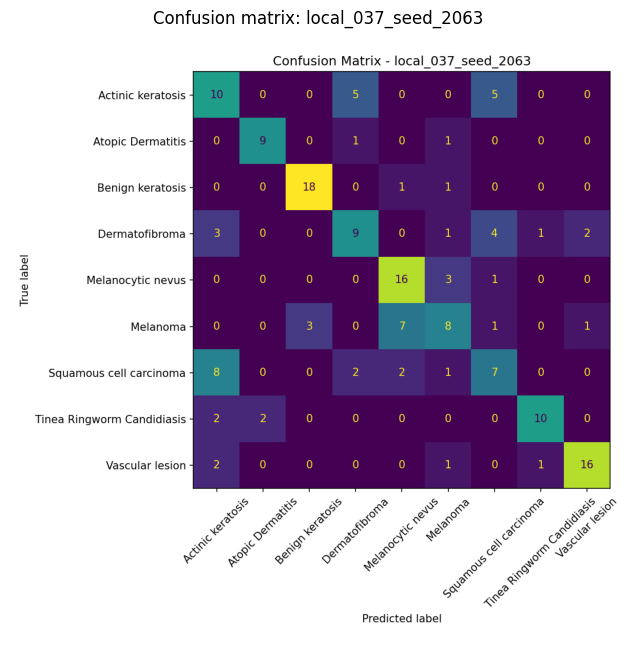

In [21]:
# Mostrar matriz de confusión del mejor run
if len(combined_results_df):
    best_label = combined_results_df.iloc[0]["run_label"]
    cm_path = f"{artifact_dir}/confusion_matrix_{best_label}.png"
    if os.path.exists(cm_path):
        img = plt.imread(cm_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Confusion matrix: {best_label}")
        plt.show()
    else:
        print("No existe:", cm_path)
